# Azobenzene S0/S1 energy surfaces

Load a labelled XYZ, derive azobenzene internal coordinates, and compare its energies with a predicted 2-D surface.

## 1. Load and normalize labels

In [66]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
from ase.io import read

# Edit this path to analyse a different labelled azobenzene XYZ file.
XYZ_NAME = Path("data/azoflip_data/XYZ/dataset/cis_trans_azobenzenes_full_soap_maxmin_10480_hartree.xyz")
HARTREE_TO_EV = 27.211386245988
BOHR_TO_ANGSTROM = 0.529177210903

def resolve_repo_path(path):
    candidates = (Path.cwd() / path, Path.cwd().parent / path)
    resolved = next((candidate for candidate in candidates if candidate.exists()), None)
    if resolved is None:
        raise FileNotFoundError(f"Could not find {path} from {Path.cwd()}")
    return resolved

def _stack_state_labels(frames, key, location):
    labels = []
    for frame_index, frame in enumerate(frames):
        if key not in location(frame):
            raise KeyError(f"{key} is missing from frame {frame_index}.")
        value = np.asarray(location(frame)[key], dtype=float)
        if not np.isfinite(value).all():
            raise ValueError(f"{key} contains non-finite values in frame {frame_index}.")
        labels.append(value)
    try:
        return np.stack(labels)
    except ValueError as error:
        raise ValueError(f"{key} has inconsistent shapes between frames.") from error

def infer_label_units(raw_energies):
    median_absolute_energy = float(np.median(np.abs(raw_energies)))
    if median_absolute_energy < 1_000.0:
        return "Hartree", "Hartree/Bohr", HARTREE_TO_EV, HARTREE_TO_EV / BOHR_TO_ANGSTROM
    if median_absolute_energy > 3_000.0:
        return "eV", "eV/Å", 1.0, 1.0
    raise ValueError(
        "Cannot infer label units safely: median |REF_energy| is "
        f"{median_absolute_energy:.3f}, between the Hartree (<1000) and eV (>3000) thresholds."
    )

def normalize_labels(frames, dataset_name):
    if not frames:
        raise ValueError(f"{dataset_name} contains no geometries.")
    raw_energies = _stack_state_labels(frames, "REF_energy", lambda frame: frame.info)
    state_energies = raw_energies.reshape(len(frames), -1)
    if state_energies.shape[1] != 2:
        raise ValueError(f"Expected two state energies per geometry, got shape {raw_energies.shape}.")
    energy_unit, force_unit, energy_factor, force_factor = infer_label_units(state_energies)
    energies_ev = state_energies * energy_factor
    force_sources = ["REF_forces" in frame.info or "REF_forces" in frame.arrays for frame in frames]
    if any(force_sources) and not all(force_sources):
        raise ValueError("REF_forces is present for only a subset of geometries.")
    forces_ev_per_angstrom = None
    if all(force_sources):
        def force_location(frame):
            return frame.info if "REF_forces" in frame.info else frame.arrays
        raw_forces = _stack_state_labels(frames, "REF_forces", force_location)
        if raw_forces.ndim != 4 or raw_forces.shape[1:] != (len(frames[0]), 2, 3):
            raise ValueError(
                "REF_forces must have shape (geometries, atoms, 2, 3); "
                f"received {raw_forces.shape}."
            )
        forces_ev_per_angstrom = raw_forces * force_factor
    print(f"Loaded {len(frames):,} geometries from {dataset_name}")
    print(f"Inferred input units: energy={energy_unit}; forces={force_unit}")
    print("Target units: energy=eV; forces=eV/Å")
    print(f"Conversion factors: energy × {energy_factor:.12g}; forces × {force_factor:.12g}")
    print("REF_forces: available and normalized" if forces_ev_per_angstrom is not None else "REF_forces: not present")
    return energies_ev, forces_ev_per_angstrom

XYZ_PATH = resolve_repo_path(XYZ_NAME)
frames = read(XYZ_PATH, index=":")
energies_ev, forces_ev_per_angstrom = normalize_labels(frames, XYZ_PATH.name)


Loaded 10,480 geometries from cis_trans_azobenzenes_full_soap_maxmin_10480_hartree.xyz
Inferred input units: energy=Hartree; forces=Hartree/Bohr
Target units: energy=eV; forces=eV/Å
Conversion factors: energy × 27.211386246; forces × 51.4220674763
REF_forces: available and normalized


## 2. Derive geometry coordinates

In [67]:
# Zero-based ASE atom indices for the azobenzene ordering used by this dataset.
NN_ATOMS = (4, 5)
NNC_LEFT_ATOMS = (3, 4, 5)
NNC_RIGHT_ATOMS = (4, 5, 6)
CNNC_ATOMS = (3, 4, 5, 6)
LEFT_RING_TORSION_ATOMS = (2, 3, 4, 5)
RIGHT_RING_TORSION_ATOMS = (4, 5, 6, 7)

def chemical_cnnc_dihedral(raw_dihedral_deg):
    """Map ASE's 0–360° CNNC dihedral to 0° cis through 180° trans."""
    centered = (np.asarray(raw_dihedral_deg) + 180.0) % 360.0 - 180.0
    return np.abs(180.0 - np.abs(centered))

raw_cnnc_dihedral_deg = np.asarray([frame.get_dihedral(*CNNC_ATOMS) for frame in frames])
left_nnc_angle_deg = np.asarray([frame.get_angle(*NNC_LEFT_ATOMS) for frame in frames])
right_nnc_angle_deg = np.asarray([frame.get_angle(*NNC_RIGHT_ATOMS) for frame in frames])
left_ring_torsion_deg = np.asarray([frame.get_dihedral(*LEFT_RING_TORSION_ATOMS) for frame in frames])
right_ring_torsion_deg = np.asarray([frame.get_dihedral(*RIGHT_RING_TORSION_ATOMS) for frame in frames])

analysis_data = pd.DataFrame({
    "N=N bond length (Å)": [frame.get_distance(*NN_ATOMS) for frame in frames],
    "Left NNC angle (°)": left_nnc_angle_deg,
    "Right NNC angle (°)": right_nnc_angle_deg,
    "Mean NNC angle (°)": 0.5 * (left_nnc_angle_deg + right_nnc_angle_deg),
    "CNNC chemical dihedral (°)": chemical_cnnc_dihedral(raw_cnnc_dihedral_deg),
    "Left ring N-C torsion (°)": left_ring_torsion_deg,
    "Right ring N-C torsion (°)": right_ring_torsion_deg,
    "Signed ring twist difference (°)": (right_ring_torsion_deg - left_ring_torsion_deg + 180.0) % 360.0 - 180.0,
    "S0 energy (eV)": energies_ev[:, 0],
    "S1 energy (eV)": energies_ev[:, 1],
})
if not np.isfinite(analysis_data.to_numpy(dtype=float)).all():
    raise ValueError("Derived geometry coordinates or energies contain non-finite values.")

nnc_mismatch = np.abs(left_nnc_angle_deg - right_nnc_angle_deg)
for column in ("N=N bond length (Å)", "Mean NNC angle (°)", "CNNC chemical dihedral (°)", "Signed ring twist difference (°)"):
    values = analysis_data[column]
    print(f"{column}: {values.min():.3f}–{values.max():.3f}")
print(f"Largest left/right NNC mismatch: {nnc_mismatch.max():.3f}°")


N=N bond length (Å): 1.083–4.634
Mean NNC angle (°): 92.393–151.268
CNNC chemical dihedral (°): 0.006–179.904
Signed ring twist difference (°): -179.995–179.999
Largest left/right NNC mismatch: 61.576°


## 3. Geometry-coordinate histograms

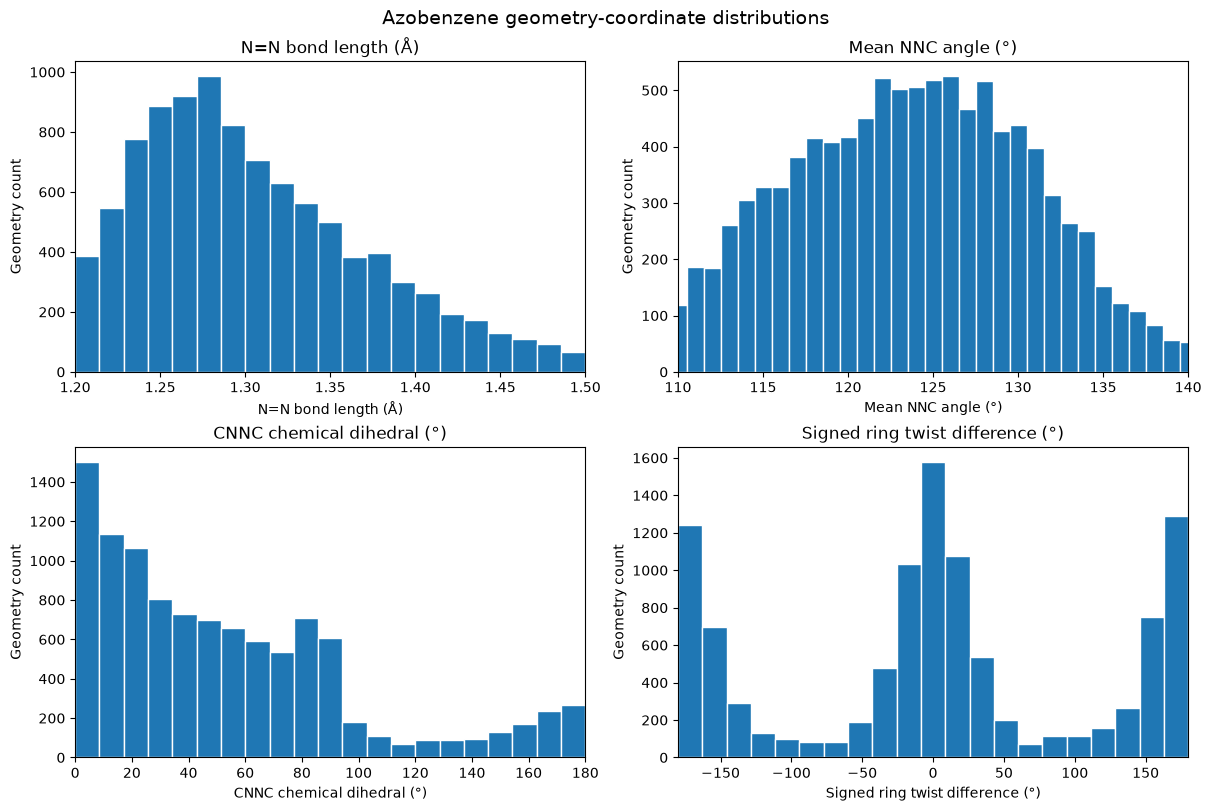

In [68]:
HISTOGRAM_COORDINATES = {
    "N=N bond length (Å)": (1.20, 1.50),
    "Mean NNC angle (°)": (110.0, 140.0),
    "CNNC chemical dihedral (°)": (0.0, 180.0),
    "Signed ring twist difference (°)": (-180.0, 180.0),
}
HISTOGRAM_BINS = {
    # One-degree bins with half-degree edges keep each 5° NNC grid value in one bin.
    "Mean NNC angle (°)": np.arange(107.5, 142.5 + 1e-9, 1.0),
}

figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for axis, (column, limits) in zip(axes.flat, HISTOGRAM_COORDINATES.items()):
    axis.hist(analysis_data[column], bins=HISTOGRAM_BINS.get(column, 21), range=limits, color="tab:blue", edgecolor="white")
    axis.set(xlim=limits, xlabel=column, ylabel="Geometry count", title=column)
figure.suptitle("Azobenzene geometry-coordinate distributions", fontsize=14)
plt.show()


## 4. Dataset points versus predicted energy surfaces

Loaded 1,147 geometries from azobenzene_2D_grid_with_variable_rotation_eV.xyz
Inferred input units: energy=Hartree; forces=Hartree/Bohr
Target units: energy=eV; forces=eV/Å
Conversion factors: energy × 27.211386246; forces × 51.4220674763
REF_forces: available and normalized


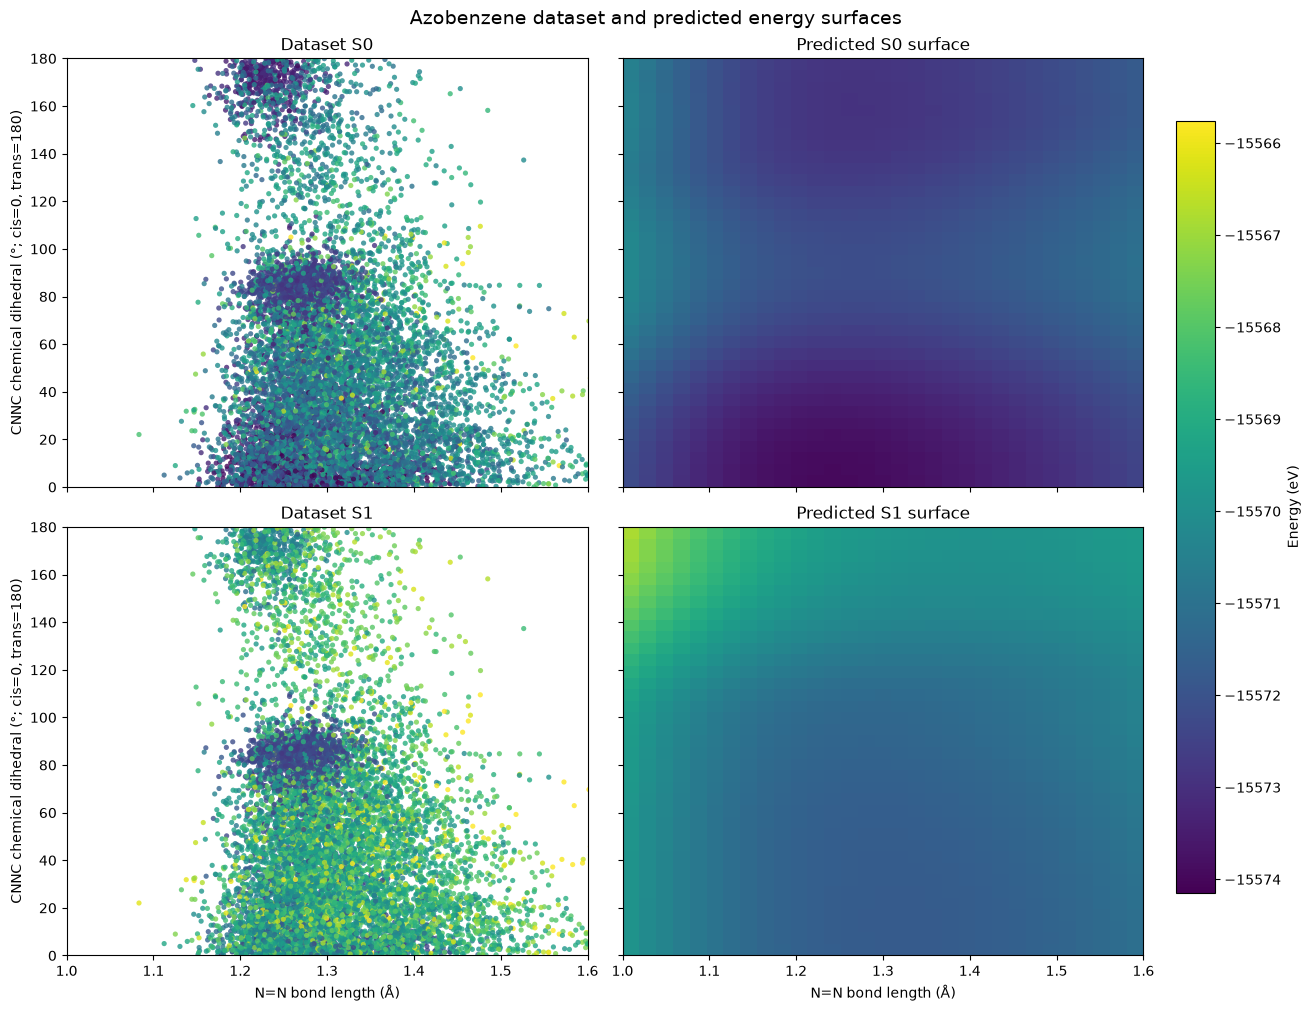

In [69]:
# Edit this path to compare against a different predicted 2-D grid.
PREDICTED_GRID_NAME = Path("data/azoflip_data/XYZ/grid/azobenzene_2D_grid_with_variable_rotation_eV.xyz")
predicted_path = resolve_repo_path(PREDICTED_GRID_NAME)
predicted_frames = read(predicted_path, index=":")
predicted_energies_ev, _ = normalize_labels(predicted_frames, predicted_path.name)

required_metadata = ("nn_distance_angstrom", "cnnc_dihedral_deg")
if any(any(key not in frame.info for key in required_metadata) for frame in predicted_frames):
    raise KeyError(f"Predicted grid must provide metadata fields {required_metadata}.")
predicted_nn = np.asarray([frame.info["nn_distance_angstrom"] for frame in predicted_frames], dtype=float)
predicted_cnnc = np.asarray([frame.info["cnnc_dihedral_deg"] for frame in predicted_frames], dtype=float)
measured_predicted_nn = np.asarray([frame.get_distance(*NN_ATOMS) for frame in predicted_frames])
measured_predicted_cnnc = chemical_cnnc_dihedral([frame.get_dihedral(*CNNC_ATOMS) for frame in predicted_frames])
if not (np.allclose(predicted_nn, measured_predicted_nn, atol=1e-5) and np.allclose(predicted_cnnc, measured_predicted_cnnc, atol=1e-5)):
    raise ValueError("Predicted-grid metadata does not match its measured N=N/CNNC coordinates.")

predicted_nn_values = np.unique(predicted_nn)
predicted_cnnc_values = np.unique(predicted_cnnc)
if len(predicted_frames) != len(predicted_nn_values) * len(predicted_cnnc_values):
    raise ValueError("Predicted grid is incomplete or contains duplicate coordinate pairs.")
predicted_energy_grid_ev = np.full((2, len(predicted_nn_values), len(predicted_cnnc_values)), np.nan)
nn_index = {value: index for index, value in enumerate(predicted_nn_values)}
cnnc_index = {value: index for index, value in enumerate(predicted_cnnc_values)}
for bond_length, dihedral, state_energies in zip(predicted_nn, predicted_cnnc, predicted_energies_ev):
    predicted_energy_grid_ev[:, nn_index[bond_length], cnnc_index[dihedral]] = state_energies
if np.isnan(predicted_energy_grid_ev).any():
    raise ValueError("Could not populate every predicted S0/S1 grid point.")

comparison_energies = np.concatenate((energies_ev.ravel(), predicted_energies_ev.ravel()))
comparison_norm = Normalize(*np.percentile(comparison_energies, (1.0, 99.0)))
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True, constrained_layout=True)
for state in range(2):
    dataset_axis, predicted_axis = axes[state]
    dataset_axis.scatter(analysis_data["N=N bond length (Å)"], analysis_data["CNNC chemical dihedral (°)"], c=analysis_data[f"S{state} energy (eV)"], cmap="viridis", norm=comparison_norm, s=14, alpha=0.8, linewidths=0)
    predicted_axis.imshow(predicted_energy_grid_ev[state].T, origin="lower", aspect="auto", extent=(predicted_nn_values[0], predicted_nn_values[-1], predicted_cnnc_values[0], predicted_cnnc_values[-1]), cmap="viridis", norm=comparison_norm, interpolation="nearest")
    dataset_axis.set(title=f"Dataset S{state}")
    predicted_axis.set(title=f"Predicted S{state} surface")
for axis in axes[-1]:
    axis.set(xlabel="N=N bond length (Å)")
for axis in axes[:, 0]:
    axis.set(ylabel="CNNC chemical dihedral (°; cis=0, trans=180)")
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=comparison_norm, cmap="viridis"), ax=axes, shrink=0.86, pad=0.02)
colorbar.set_label("Energy (eV)")
fig.suptitle("Azobenzene dataset and predicted energy surfaces", fontsize=14)
plt.show()


## 5. Pairwise geometry relationships

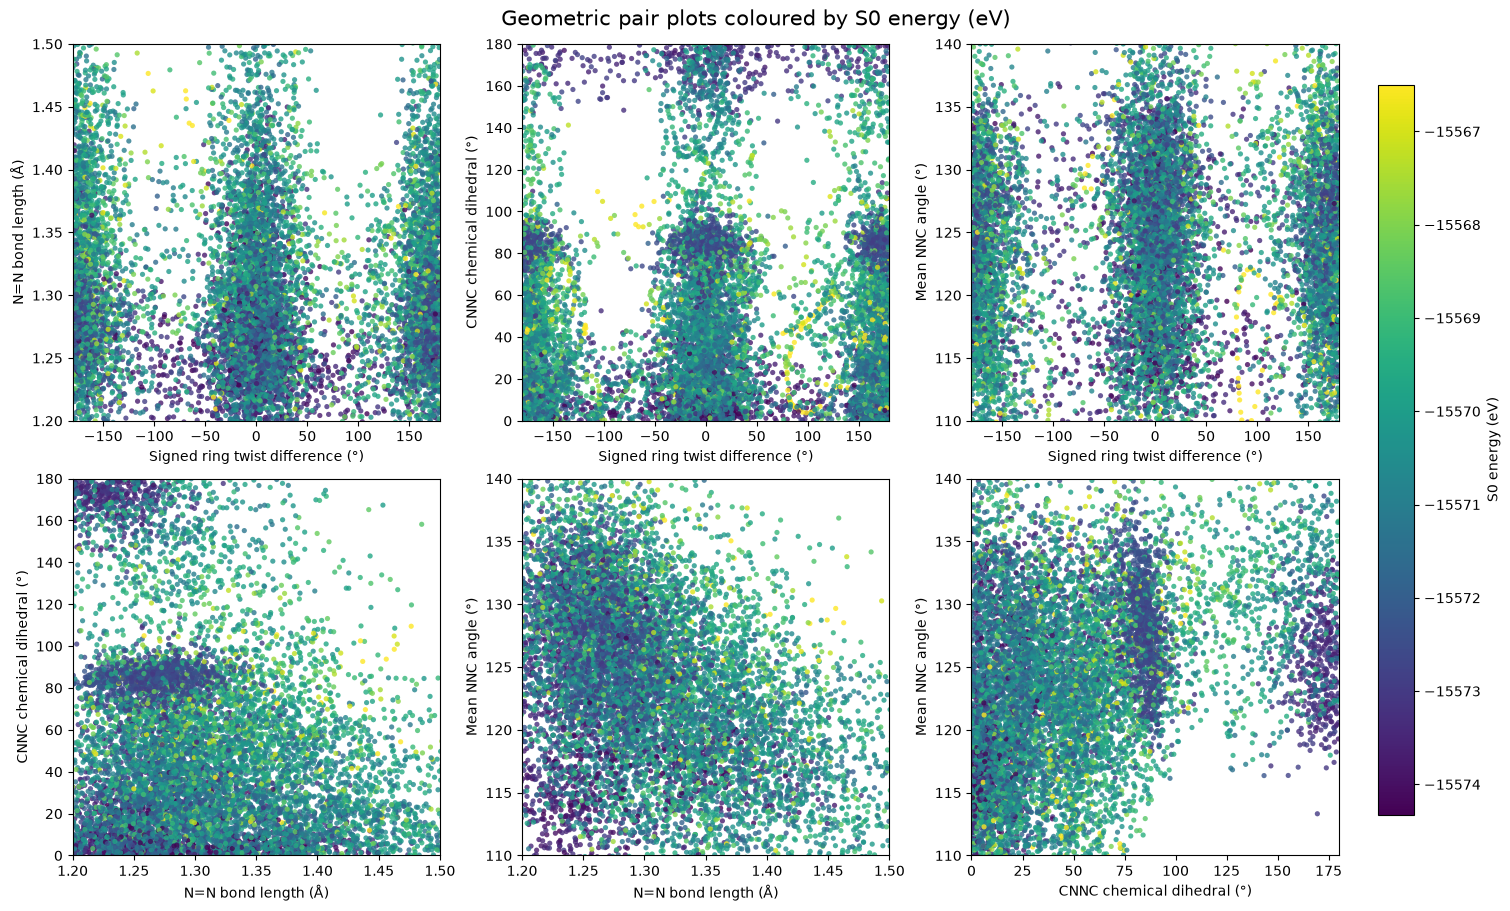

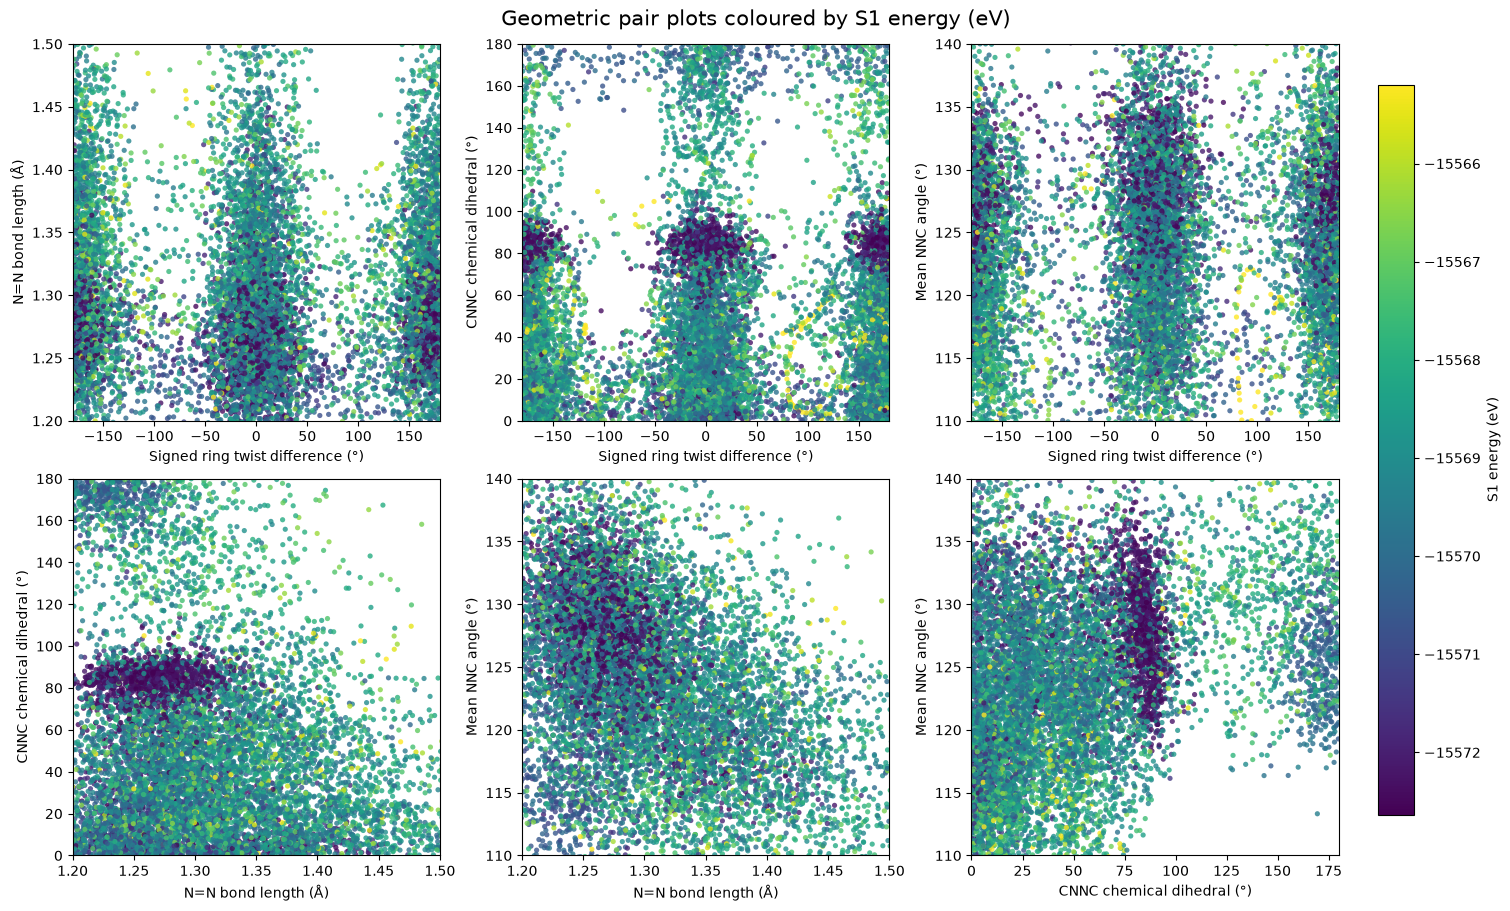

In [70]:
from itertools import combinations

GEOMETRY_COLUMNS = ["Signed ring twist difference (°)", "N=N bond length (Å)", "CNNC chemical dihedral (°)", "Mean NNC angle (°)"]
GEOMETRY_LIMITS = {
    "Signed ring twist difference (°)": (-180.0, 180.0),
    "N=N bond length (Å)": (1.20, 1.50),
    "CNNC chemical dihedral (°)": (0.0, 180.0),
    "Mean NNC angle (°)": (110.0, 140.0),
}

def plot_energy_coloured_pairs(energy_column):
    color_norm = Normalize(*np.percentile(analysis_data[energy_column], (1.0, 99.0)))
    figure, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
    for axis, (x_column, y_column) in zip(axes.flat, combinations(GEOMETRY_COLUMNS, 2)):
        axis.scatter(analysis_data[x_column], analysis_data[y_column], c=analysis_data[energy_column], cmap="viridis", norm=color_norm, s=14, alpha=0.8, linewidths=0, rasterized=True)
        axis.set(xlim=GEOMETRY_LIMITS[x_column], ylim=GEOMETRY_LIMITS[y_column], xlabel=x_column, ylabel=y_column)
    colorbar = figure.colorbar(plt.cm.ScalarMappable(norm=color_norm, cmap="viridis"), ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
    colorbar.set_label(energy_column)
    figure.suptitle(f"Geometric pair plots coloured by {energy_column}", fontsize=15)
    plt.show()

plot_energy_coloured_pairs("S0 energy (eV)")
plot_energy_coloured_pairs("S1 energy (eV)")
